# Image Classifier — PyTorch

Binary CNN classifier: **person** vs **not_person**.

Uses `./processed_images/` with subdirectories `person/` and `not_person/`  
loaded via `torchvision.datasets.ImageFolder` — no filename-based label inference needed.

**Install:** `pip install torch torchvision matplotlib pillow`

## 1. Imports

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

# reproducibility
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


## 2. Config — edit these to match your setup

In [2]:
PROCESSED_DIR = './processed_images'   # must contain person/ and not_person/ subdirs
IMG_SIZE      = (224, 224)   # resize target (H, W)
BATCH_SIZE    = 16           # try 16, 32, 64
EPOCHS        = 10
LR            = 1e-3
VAL_SPLIT     = 0.2          # 20 % held out for validation
CLASSES       = ['not_person', 'person']  # ImageFolder sorts alphabetically → index 0 / 1

## 3. Check dataset folder

In [3]:
import os

for cls in ['person', 'not_person']:
    folder = os.path.join(PROCESSED_DIR, cls)
    files  = [f for f in os.listdir(folder) if f.lower().endswith('.png')]
    print(f"  {cls}: {len(files)} images")

print(f"\nTotal: {sum(len(os.listdir(os.path.join(PROCESSED_DIR, c))) for c in ['person','not_person'])} images")

  person: 8 images
  not_person: 7 images

Total: 15 images


## 4. Dataset

`ImageFolder` reads the subdirectory names as class labels automatically.  
Classes are sorted alphabetically: `not_person=0`, `person=1`.

In [4]:
from torchvision import datasets
from torch.utils.data import random_split, DataLoader
import torchvision.transforms as transforms

# Training: augment to help generalisation on a small dataset
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Validation: resize + normalise only
val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Load full dataset with training transforms first
full_dataset = datasets.ImageFolder(root=PROCESSED_DIR, transform=train_transform)
CLASSES = full_dataset.classes   # confirmed from folder names
print(f"Classes detected: {CLASSES}")

# Train / val split
val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply non-augmenting transform to validation split
val_ds.dataset.transform = val_transform

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {train_size} images   Val: {val_size} images")
print(f"Batches per epoch (train): {len(train_loader)}")

# Class distribution
all_labels = [label for _, label in full_dataset.samples]
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {all_labels.count(i)}")

Classes detected: ['not_person', 'person']
Train: 12 images   Val: 3 images
Batches per epoch (train): 1
  not_person: 7
  person: 8


## 5. Visualise a batch  _(sanity check labels)_

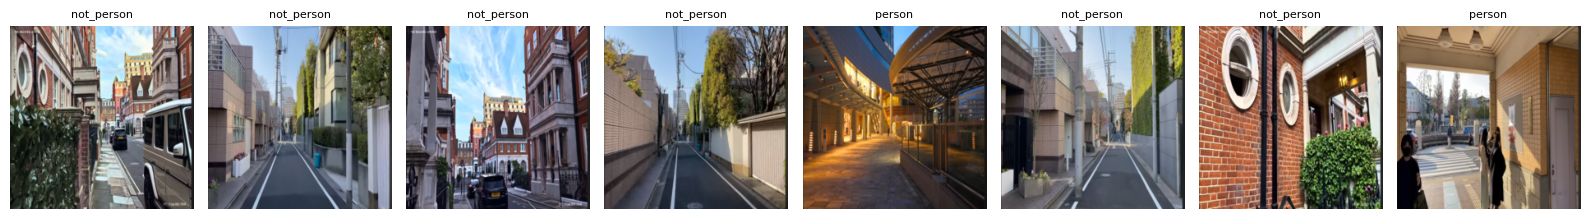

In [6]:
def denorm(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

imgs, lbls = next(iter(train_loader))
n_show = min(8, len(imgs))

fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 3))
for i in range(n_show):
    ax = axes[i]
    ax.imshow(denorm(imgs[i]).permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[lbls[i].item()], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Model — CNN

3× Conv→BN→ReLU→MaxPool blocks, then a fully-connected head.

In [7]:
class PersonCNN(nn.Module):
    """Simple CNN binary classifier.
    Input : (N, 3, H, W)
    Output: (N, 1)  raw logit  — use BCEWithLogitsLoss
    """

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # block 1
            nn.Conv2d(3,  16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # /2
            # block 2
            nn.Conv2d(16, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # /4
            # block 3
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # /8
        )
        # after 3× MaxPool on 224×224 → 28×28
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 1),        # binary → single logit
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = PersonCNN().to(device)
print(model)

# quick parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

PersonCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
  

## 7. Loss, optimiser, and LR scheduler

In [8]:
criterion = nn.BCEWithLogitsLoss()          # numerically stable binary cross-entropy
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3)

## 8. Training loop

In [9]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # (N,) → (N,1)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = (torch.sigmoid(logits) >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        preds       = (torch.sigmoid(logits) >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


# ── run ───────────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f}  "
          f"val loss={vl_loss:.4f} acc={vl_acc:.3f}")

    # save best checkpoint
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ best model saved (val_loss={best_val_loss:.4f})")

print("Training complete.")

Epoch 01/10  train loss=0.7594 acc=0.417  val loss=0.8730 acc=0.333
  ✓ best model saved (val_loss=0.8730)
Epoch 02/10  train loss=0.0070 acc=1.000  val loss=0.8606 acc=0.333
  ✓ best model saved (val_loss=0.8606)
Epoch 03/10  train loss=0.0021 acc=1.000  val loss=0.6980 acc=0.667
  ✓ best model saved (val_loss=0.6980)
Epoch 04/10  train loss=0.0000 acc=1.000  val loss=1.2716 acc=0.667
Epoch 05/10  train loss=1.4204 acc=0.917  val loss=0.9705 acc=0.667
Epoch 06/10  train loss=0.0000 acc=1.000  val loss=0.6423 acc=0.667
  ✓ best model saved (val_loss=0.6423)
Epoch 07/10  train loss=3.6269 acc=0.917  val loss=1.4714 acc=0.667
Epoch 08/10  train loss=2.6005 acc=0.833  val loss=4.6381 acc=0.667
Epoch 09/10  train loss=1.9867 acc=0.917  val loss=5.4758 acc=0.667
Epoch 10/10  train loss=1.3823 acc=0.917  val loss=5.4004 acc=0.667
Training complete.


## 9. Plot training curves

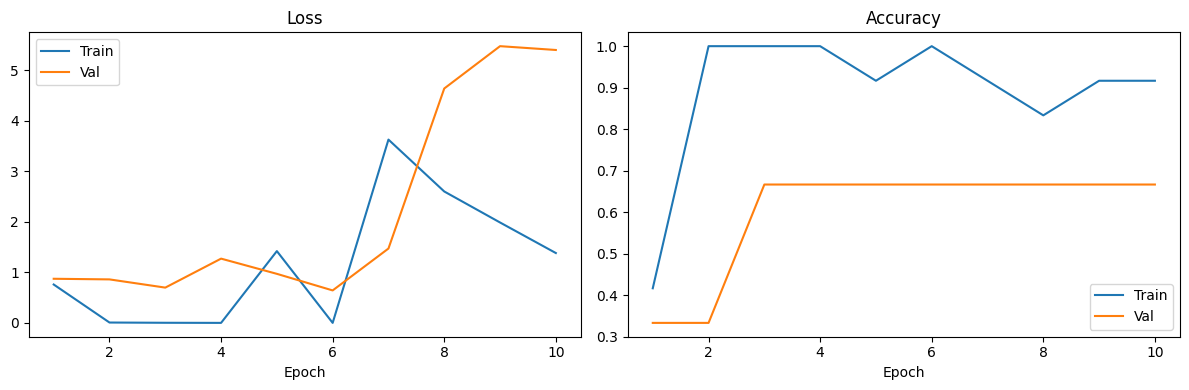

In [10]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history['train_loss'], label='Train')
ax1.plot(epochs_range, history['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(epochs_range, history['train_acc'], label='Train')
ax2.plot(epochs_range, history['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.show()

## 10. Evaluate on validation set (load best checkpoint)

In [11]:
model.load_state_dict(torch.load('best_model.pth', map_location=device))
val_loss, val_acc = eval_epoch(model, val_loader, criterion)
print(f"Best model — val loss: {val_loss:.4f}  val accuracy: {val_acc:.3f}")

Best model — val loss: 0.6423  val accuracy: 0.667


## 11. Predict on a single image

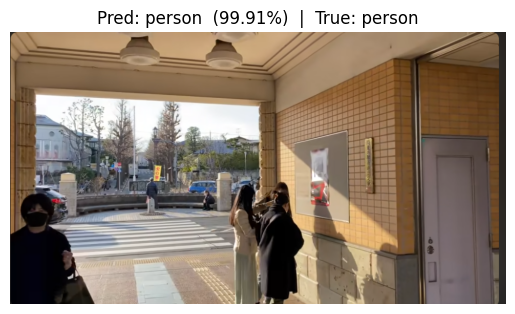

File: screenshot-2026-04-01T17-16-44-233Z_person.png


In [12]:
def predict(image_path, model, transform, device, classes):
    """Run inference on a single image file."""
    model.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logit = model(tensor)
        prob  = torch.sigmoid(logit).item()

    label = classes[1] if prob >= 0.5 else classes[0]
    return label, prob


# Pick a random image from processed_images (any subdir)
all_samples = full_dataset.samples   # list of (path, label_idx)
test_path, true_idx = random.choice(all_samples)
pred_label, confidence = predict(test_path, model, val_transform, device, CLASSES)

img = Image.open(test_path)
plt.imshow(img)
plt.title(f"Pred: {pred_label}  ({confidence:.2%})  |  True: {CLASSES[true_idx]}")
plt.axis('off')
plt.show()
print(f"File: {os.path.basename(test_path)}")

## 12. Save & load the full model

PyTorch best practice is to save `state_dict` (weights only).  
For portability you can also export to ONNX.

In [13]:
# ── save weights ──────────────────────────────────────────────────────────────
torch.save(model.state_dict(), 'person_classifier.pth')
print("Weights saved to person_classifier.pth")

# ── reload example ────────────────────────────────────────────────────────────
loaded_model = PersonCNN().to(device)
loaded_model.load_state_dict(torch.load('person_classifier.pth', map_location=device))
loaded_model.eval()
print("Model reloaded successfully.")

# ── optional: export to ONNX ─────────────────────────────────────────────────
# dummy_input = torch.randn(1, 3, *IMG_SIZE).to(device)
# torch.onnx.export(
#     model, dummy_input, 'person_classifier.onnx',
#     input_names=['image'], output_names=['logit'],
#     dynamic_axes={'image': {0: 'batch_size'}},
#     opset_version=17
# )
# print("ONNX model saved to person_classifier.onnx")

Weights saved to person_classifier.pth
Model reloaded successfully.
